This code can calculate reflectance and transmittence across the wavelenghth spectrum. You neet to be careful about your exell file because if n2 is a metal there should be almost not transmittence. Also n0 and n2 shouldnt have complex components because it cant be graphed. I also just had an Idea for compiling a very useful code. In my plotting functions I have these if else statements. I could add any number of if statements as long as i have an else statement. This way a single code could have multiple function modes. 

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


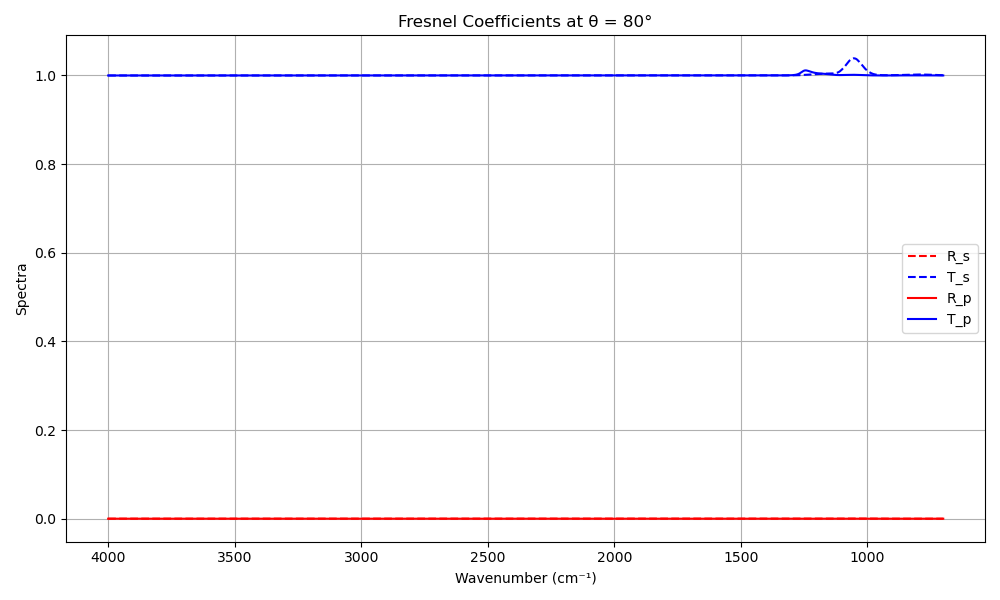

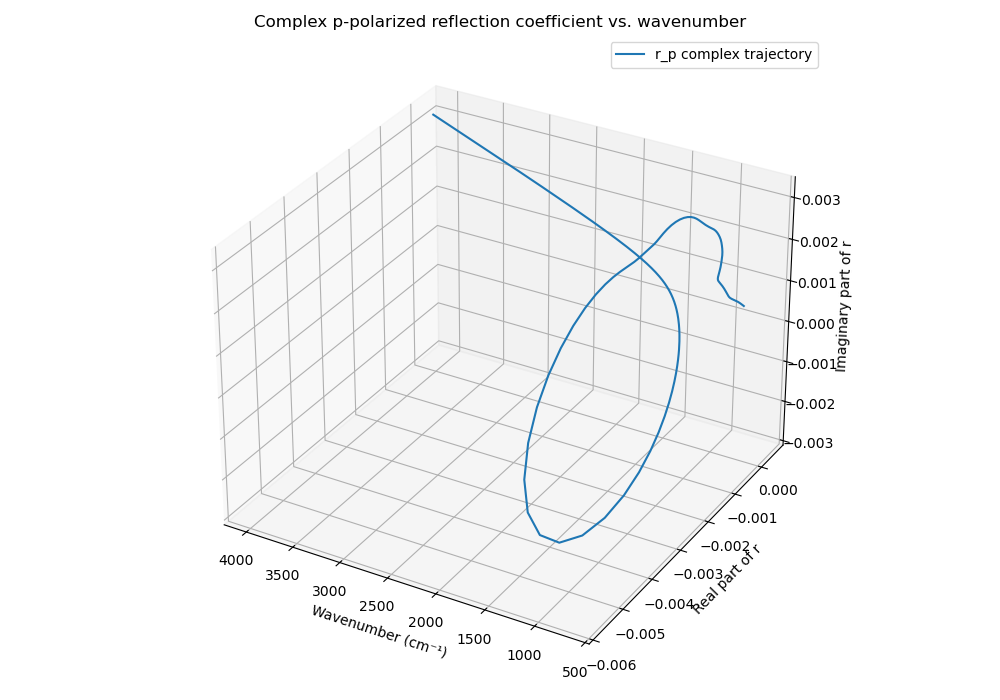

In [13]:
%matplotlib widget 

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd     

file_path = "/Users/josephschellenberg/Downloads/Fresnell.xlsx"
# Load the Excel file (adjust path/filename as needed)
df = pd.read_excel("/Users/josephschellenberg/Downloads/Fresnell/Fresnell.xlsx")  # Or .csv with pd.read_csv

# Extract columns into arrays
wave_numbers = df["wave_numbers"].values
n0_array = df["n0"].values
k0_array = df["k0"].values
n1_array = df["n1"].values
k1_array = df["k1"].values
n2_array = df["n2"].values
k2_array = df["k2"].values 


def plot_vs_wavenumber(wave_numbers, n0_array, n1_array, n2_array, 
                       k0_array, k1_array, k2_array, d, th0, mode="Reflectance and Transmittence"):
    R_p, R_s, T_p, T_s = [], [], [], []

    for i in range(len(wave_numbers)):
        n0, n1, n2 = n0_array[i], n1_array[i], n2_array[i]
        k0, k1, k2 = k0_array[i], k1_array[i], k2_array[i]
        Wavelength = 10000 / wave_numbers[i]  # Convert from cm⁻¹ to nm or μm
        cos_th0 = cos(th0)
        th1 = snells(n0, n1, k0, k1, th0)
        cos_th1 = cos(th1) 
        th2 = snells(n1, n2, k1, k2, th1)
        cos_th2= cos(th2)
        r_p = r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        r_s = r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        t_p = t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        t_s = t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)

        if mode == "Reflectance and Transmittence":
            R_p.append(np.abs(r_p)**2)
            R_s.append(np.abs(r_s)**2)
            T_p.append((n2+k2)*cos_th2*(np.abs(t_p)**2)/(n0+k0)/cos_th0)
            T_s.append((n2+k2)*cos_th2*(np.abs(t_s)**2)/(n0+k0)/cos_th0)
        else:
            R_p.append(r_p)
            R_s.append(r_s)
            T_p.append(t_p)
            T_s.append(t_s)

    plt.figure(figsize=(10, 6))
    plt.plot(wave_numbers, R_s, 'r--', label='R_s')
    plt.plot(wave_numbers, T_s, 'b--', label='T_s')
    plt.plot(wave_numbers, R_p, 'r-', label='R_p')
    plt.plot(wave_numbers, T_p, 'b-', label='T_p')
    plt.xlabel("Wavenumber (cm⁻¹)")
    plt.ylabel("Reflectance and Transmittence" if mode == "abs" else "Spectra")
    plt.title(f"Fresnel Coefficients at θ = {th0}°")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.gca().invert_xaxis()
    plt.show()


def cos(th):
    return np.cos(th*np.pi/180) 

def costht(ni, nt, ki, kt, thi):
    return(np.sqrt(1-((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2)) 

def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi 

def sin(th):
    return np.sin(th*np.pi/180) 

# 3 Returns transmitted angle from incident angle
def snells(ni, nt, ki, kt, thi):
    return(arcsin((ni+1j*ki)/(nt+1j*kt)*sin(thi)))



# 4 General form of fresnel coefficients for s polarized light (perpindicular electric field) 
def r_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(((ni+1j*ki)/mui*cos_thi-(nt+1j*kt)/mut*cos_tht)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht)) 

def t_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)  
    return((2*(ni+1j*ki)/mui*cos_thi)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht))

# 5 General form of fresnel coefficients for p polarized light (parrallel electric field)  

def r_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((-(nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))

def t_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((2*(ni+1j*ki)/mui*cos_thi)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))  


#transmission matrix 

def D_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((1/t_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12))*(np.array([[1,r_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12)],[r_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12),1]])))  

def D_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((1/t_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12))*(np.array([[1,r_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12)],[r_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12),1]])))  


# propagation matrix wich is independant of polarazation

def P(ni, nt, ki, kt, thi, d, Wavelength):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(np.array([[np.exp(1j*2*np.pi*d*(nt+1j*kt)*cos_tht/Wavelength),0],[0,np.exp(-1j*2*np.pi*d*(nt+1j*kt)*cos_tht/Wavelength)]]))


def t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1) 
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    return(1/M_11) 


def t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1) 
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0]
    return(1/M_11)   

def r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    M_21 = M[1, 0]
    return(M_21/M_11) 

def r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0] 
    M_21 = M[1, 0]
    return(M_21/M_11)  







plot_vs_wavenumber(wave_numbers, n0_array, n1_array, n2_array, k0_array, k1_array, k2_array, d=.001, th0=80)  #d needs to be in micro meters.  


from mpl_toolkits.mplot3d import Axes3D

def plot_complex_r_3D(wave_numbers, n0_array, n1_array, n2_array, 
                      k0_array, k1_array, k2_array, d, th0, polarization='p'):
    
    real_vals, imag_vals = [], []
    for i in range(len(wave_numbers)):
        n0, n1, n2 = n0_array[i], n1_array[i], n2_array[i]
        k0, k1, k2 = k0_array[i], k1_array[i], k2_array[i]
        Wavelength = 10000 / wave_numbers[i]  # Convert from cm⁻¹ to nm or μm
        
        if polarization == 'p':
            r = r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        else:
            r = r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        
        real_vals.append(np.real(r))
        imag_vals.append(np.imag(r))

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(wave_numbers, real_vals, imag_vals, label=f'r_{polarization} complex trajectory')
    ax.set_xlabel('Wavenumber (cm⁻¹)')
    ax.set_ylabel('Real part of r')
    ax.set_zlabel('Imaginary part of r')
    ax.set_title(f'Complex {polarization}-polarized reflection coefficient vs. wavenumber')
    ax.invert_xaxis()
    ax.legend()
    plt.tight_layout()
    plt.show()   


plot_complex_r_3D(wave_numbers, n0_array, n1_array, n2_array, 
                  k0_array, k1_array, k2_array, d=0.001, th0=80, polarization='p')